## PARIS inverse modelling results - notebook edited to produce NIR/NISC style plots

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `m_data` dictionary to point towards the experiment/model you want to plot.

3. Run the cell below, before running any of the plotting code.

In [57]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func
import copy

### Path to results directory 
data_dir = '/project/InTEM_GHG/inversion/PARIS_results_sharing/'

### Set ppt_mode to True for bigger fonts
ppt_mode = False

###################################

s_data,m_data,m_colors,annotate_coords = func.initialize_settings(ppt_mode)

species_prior = {'hfc134a':'EDGAR',
                 'hfc143a':'EDGAR',
                 'hfc125':'EDGAR',
                 'hfc32':'EDGAR',
                 'hfc23':'FLAT',
                 'hfc152a':'FLAT',
                 'hfc365':'FLAT',
                 'hfc4310mee':'FLAT',
                 'hfc245fa':'FLAT',
                 'hfc227ea':'FLAT',
                 'pfc218':'FLAT',
                 'pfc318':'FLAT',
                 'pfc116':'EDGARMINVAL',
                 'cf4':'EDGARMINVAL'}

m_data = {'intem_n2o_longrun':              {'filename':'InTEM_NAME_EUROPE_EDGAR_1site_intem_obs_intem_baseline_optimized',
                                             'label':'InTEM 3yr 1site'},
          'intem_n2o_shortrun_monthly':     {'filename':'InTEM_NAME_EUROPE_EDGAR_26sites_intem_obs_intem_baseline_optimized',
                                             'label':'InTEM 1mth 26sites'},
          'intem_n2o_longrun_monthly':      {'filename':'InTEM_NAME_EUROPE_EDGAR_longrun_26sites_intem_obs_intem_baseline_optimized',
                                             'label':'InTEM 1mth 26sites'},
          'intem_ch4_shortrun_monthly':     {'filename':'InTEM_NAME_EUROPE_EDGARWETCHART_31sites_intem_obs_intem_baseline_optimized',
                                             'label':'InTEM 1mth 31sites'},
          'intem_ch4_longrun':              {'filename':'InTEM_NAME_EUROPE_EDGARWETCHART_31sites_intem_obs_intem_baseline_optimized',
                                             'label':'InTEM 2yr 2sites'},
          'intem_species_1yr':          {'filename':'InTEM_NAME_EUROPE_*_2008_1yr_inv_longrun',
                                             'label':'InTEM 1yr'},
          'intem_species_2yr':          {'filename':'InTEM_NAME_EUROPE_*_longrun_intem_obs_intem_baseline_optimized',
                                             'label':'InTEM 2yr'}
        }

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [60]:
###################################
### edit variables in this block
species = 'n2o' #options for individual species, or 'all_hfc' or 'all_pfc'
if 'hfc' in species or 'pfc' in species:
    if 'all' in species:
        models = ['intem','intem_longrun']
        s_data,m_data,m_colors,annotate_coords = func.initialize_settings(ppt_mode)
    else:
        models = [f'intem_species_1yr','intem_species_2yr']
elif species == 'ch4':
    models = [f'intem_{species}_shortrun_monthly']
    period_override = ['monthly']
elif species == 'n2o':
    models = [f'intem_{species}_longrun_monthly',f'intem_{species}_longrun']
    period_override = ['monthly','yearly']
    
regions = ['UK']
scale_co2eq = True
start_date = '1990-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2024-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year

# used to update priors in filesnames, based on the species and the species_prior dictionary above
m_data_updated = copy.deepcopy(m_data)
if 'hfc' in species or 'pfc' in species:
    if 'all' not in species:
        for k in m_data.keys():
            m_data_updated[k]['filename'] = m_data[k]['filename'].replace('*',species_prior[species])
###################################

ds_all_flux_scaled = {}

if 'all' in species:
    ds_all_flux_scaled = func.read_flux_total_fgases(data_dir,species,models,s_data,m_data_updated,
                                                     regions,start_date,end_date,
                                                     period_override=period_override)
else:
    ds_all_flux = func.read_flux(data_dir,species,models,s_data,m_data_updated,period_override=period_override)

    for m in models:
        ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,s_data,scale_units=True,
                                                scale_co2eq=scale_co2eq,
                                    species=species)[m]

model_colors = func.set_model_colors_2(models,m_colors)


Attempting to read data from intem_n2o_longrun_monthly
Reading data from: /project/InTEM_GHG/inversion/PARIS_results_sharing/InTEM/n2o/InTEM_NAME_EUROPE_EDGAR_longrun_26sites_intem_obs_intem_baseline_optimized_n2o_monthly.nc
Done!

Attempting to read data from intem_n2o_longrun
Reading data from: /project/InTEM_GHG/inversion/PARIS_results_sharing/InTEM/n2o/InTEM_NAME_EUROPE_EDGAR_1site_intem_obs_intem_baseline_optimized_n2o_yearly.nc
Done!

Masking data from intem_n2o_longrun_monthly
Scaling intem_n2o_longrun_monthly country fluxes by 265000000000.0

Masking data from intem_n2o_longrun
Scaling intem_n2o_longrun country fluxes by 265000000000.0


#### Timeseries of country fluxes:

NOTE: If all the data is not within axis limits, adjust the set_ylim parameter


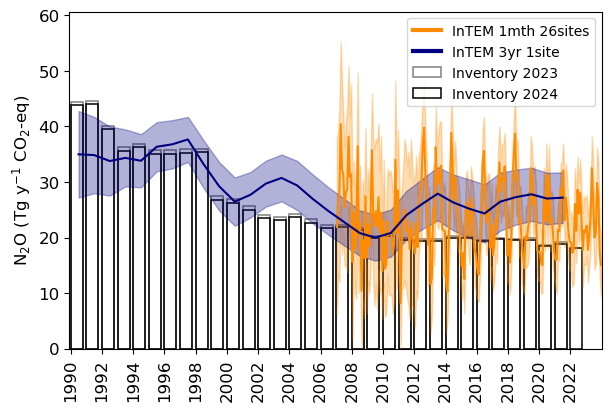

In [61]:
###################################
### edit variables in this block
plot_inventory = True
inventory_years = ['2023','2024'] #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = False #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles
skip_country_title = True
plot_separate = True #If True, includes all model results as separate lines
plot_combined = False #If True, combined results, averaged from all models
resample = None #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
update_uncert_in_resample = True #If False, uses mean uncertainty during resampling, if True, recalculates uncertainty assuming no correlation
plot_resample_and_original = False #If True, plots both the resampled and original data
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
plot_grid = False #If True, includes background light grey gridlines
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,regions,
                             s_data,m_data,model_colors,start_date,end_date,ppt_mode,scale_co2eq,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             skip_country_title=skip_country_title,
                             plot_separate=plot_separate,plot_combined=plot_combined,
                             resample=resample,update_uncert_in_resample=update_uncert_in_resample,
                             plot_resample_and_original=plot_resample_and_original,
                             period_override=period_override,
                             plot_grid=plot_grid)

Save plot here:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/flux_country.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [42]:
###################################
### edit variables in this block
species = 'ch4' #options for individual species, or 'all_hfc' or 'all_pfc'
if 'hfc' in species or 'pfc' in species:
    models = [f'intem_species_2yr']
    period_override = ['yearly']
elif species == 'ch4':
    models = [f'intem_{species}_shortrun_monthly']
    period_override = ['monthly']
elif species == 'n2o':
    models = [f'intem_{species}_longrun']
    period_override = ['yearly']
    
regions = ['UK']
scale_co2eq = True
start_date = '2019-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2024-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year

# used to update priors in filesnames, based on the species and the species_prior dictionary above
m_data_updated = copy.deepcopy(m_data)
if 'hfc' in species or 'pfc' in species:
    for k in m_data.keys():
        m_data_updated[k]['filename'] = m_data[k]['filename'].replace('*',species_prior[species])


###################################

ds_all_flux = func.read_flux(data_dir,species,models,s_data,m_data,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,s_data,scale_units=True,
                                            scale_co2eq=False,
                                species=species)[m]

model_colors = func.set_model_colors_2(models,m_colors)


Attempting to read data from intem_ch4_shortrun_monthly
Reading data from: /project/InTEM_GHG/inversion/PARIS_results_sharing/InTEM/ch4/InTEM_NAME_EUROPE_EDGARWETCHART_31sites_intem_obs_intem_baseline_optimized_ch4_monthly.nc
Done!

Masking data from intem_ch4_shortrun_monthly
Scaling intem_ch4_shortrun_monthly country fluxes by 1000000000.0


##### Plot prior, posterior or difference fluxes per time interval:


Plotting markers for: ['london', 'cardiff', 'edinburgh', 'belfast', 'dublin', 'manchester', 'birmingham']
Edit lines below line 3321 to change marker colour


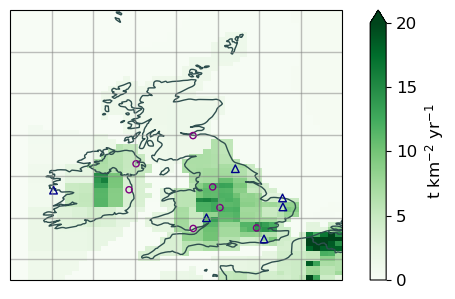

In [43]:
###################################
### edit variables in this block
plot_area = 'UK'       #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'Greens'         #flux colour (e.g. 'viridis', 'coolwarm')
c_border = 'darkslategrey' #country boundary colour (e.g. 'floralwhite', 'dimgrey')
chop_by = ['2019-01-01']  #time unit of the averaging period (options for 'year', 'month' and 'season')
                  #alternatively, a list of starting dates can be provided (format '2018-01-01')
dt = 1   #number of time steps (in chop_by units) to use in the averaging
         #if chop_by='season': set dt to a list of lists with the months to use in the average (e.g. dt=[[1,2],[10,11]], will average over Jan-Feb and Oct-Nov)
var = 'flux_total_posterior'  #variable to be plotted. Options for: 'flux_total_posterior', 'flux_total_prior', 'posterior_prior_diff'
plot_site_locations = True    #If True, adds markers to plots at locations of obs sites
plot_point_markers = ['london','cardiff','edinburgh',
                      'belfast','dublin','manchester','birmingham'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
plot_inversion_grid_flux = True #If True, plots fluxes at resolution of inversion, if False, plots at the resolution of the prior
scale_to_kgkm2yr = True #If True, outputs fluxes in kg/km2/year. If False, uses mol/m2/s.
nir_style_plot = True #If True, uses triangles to mark obs sites and circles for points listed in point_source_markers
###################################

fig = func.plot_spatial_flux_per_timestamp(ds_all_flux_scaled,species,plot_area,end_date,s_data,m_data,
                                            cmap=cmap,c_border=c_border,
                                            var=var,chop_by=chop_by,dt=dt,period_override=period_override,
                                            plot_site_locations=plot_site_locations,
                                            plot_point_markers=plot_point_markers,
                                            plot_inversion_grid_flux=plot_inversion_grid_flux,
                                            scale_to_kgkm2yr=scale_to_kgkm2yr,
                                            nir_style_plot=nir_style_plot)

#### Save plot:

In [ ]:
output_path = f'/home/h02/aramsden/results/NIR/2024_10_NISC/spatial_emissions_{species}_TEST.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Prior and posterior fluxes for all models:

In [ ]:
###################################
### edit variables in this block
plot_area = 'UK' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'Greens'   #Greens
cmap_diff = 'coolwarm'
c_border = 'dimgrey'    #country boundary colour
plot_site_locations = True #If True, adds markers to plots at locations of obs sites 
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
season = None #If specified plot the seasonal mean (only valable for monthly data). Options for 'DJF', 'MAM', 'JJA' and 'SON'
plot_inversion_grid_flux = True #If True, plots fluxes at resolution of inversion, if False, plots at the resolution of the prior
NISC_plot = True
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,s_data,m_data,
                             cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                             period_override=period_override,plot_site_locations=plot_site_locations,
                             plot_point_markers=plot_point_markers,
                             season=season,plot_inversion_grid_flux=plot_inversion_grid_flux)

##### Directly compare posterior fluxes from two models:

In [ ]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,s_data,m_data,ppt_mode,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers,
                                        season=season,
                                        plot_inversion_grid_flux=plot_inversion_grid_flux)

### 3. Modelled and observed mole fractions and/or baselines - this has not been edited from the original PARIS notebook

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
###################################
### edit variables in this block
species = 'hfc134a' 
site = 'MHD'
models = experiments['std_run']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive
end_date = '2019-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs                - total observed mole fraction
# uYobs_repeatability - observed repeatability mole fraction uncertainty
# uYobs_variability   - observed variability mole fraction uncertainty
# uYmod               - model mole fraction uncertainty
# uYtotal             - total mole fraction uncertainty
# Yapriori            - prior total mole fraction
# Yapost              - posterior total mole fraction
# YaprioriBC          - prior baseline
# YapostBC            - posterior baseline
# Ybias               - posterior bias added to site
# YaprioriOuter       - prior mole fractions only from outer regions
# YapostOuter         - posterior mole fractions only from outer regions
###################################


ds_all_mf = func.read_mf(data_dir,species,models,s_data,m_data,period_override=period_override)

ds_all_mf_sliced = func.slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

model_colors = func.set_model_colors_2(models,m_colors)

#### Plot timestamps with data at each site:

In [ ]:
fig = func.plot_sites_timeseries(ds_all_mf,'Yapost',start_date,end_date,model_colors,m_data)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/sites.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, separated by model:

In [ ]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,
                                    model_colors,s_data,m_data,annotate_coords,ppt_mode,
                                    include=['Yobs','Yapost'],
                                    diff_include=['Yapost'],
                                    y_lim=None)

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
# - To choose y axis limits set y_lim=[min_value,max_value]
###################################

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_timeseries.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,
                                    model_colors,s_data,m_data,annotate_coords,ppt_mode,
                                    include=['Yapost'],
                                    diff_include=['Yapost'],
                                    y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_allmodels.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,
                        model_colors,s_data,m_data,annotate_coords,ppt_mode,
                        include=['Yapost'],
                        diff_include=['Yapost'],
                        y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_diff.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites)

fig = func.plot_stats_mf(pearson,nrmse,species,
                         model_colors,s_data,m_data,
                         start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)